## ═══════════════════════════════════════════════════════
## GRAPH BASED TRAFFIC CONGESTION PREDICTION IN YAOUNDÉ USING ROAD NETWORK ANALYTICS AND MACHINE LEARNING
## ═══════════════════════════════════════════════════════

## ═══════════════════════════════════════════════════════
## Master Notebook — All Phases
## ═══════════════════════════════════════════════════════

In [14]:

## CELL 1 — Master Imports & Project Setup

import os, sys, pickle, sqlite3, warnings
from datetime import datetime
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import osmnx as ox
import networkx as nx
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, SAGEConv
import openrouteservice
from apscheduler.schedulers.background import BackgroundScheduler

# Project paths
BASE      = r"C:\Users\LUM\Documents\yaoundé-traffic"
DATA      = os.path.join(BASE, "data")
PROCESSED = os.path.join(BASE, "processed")
MODELS    = os.path.join(BASE, "models")
APP       = os.path.join(BASE, "app")
F1        = os.path.join(DATA, "Supp. Material I - Household_survey.xlsx")
F2        = os.path.join(DATA, "Supp. Material II - Vehicle Speed_POI_Emission.xlsx")

# Create folders if missing
for path in [DATA, PROCESSED, MODELS, APP]:
    os.makedirs(path, exist_ok=True)

print("=" * 50)
print("YAOUNDÉ TRAFFIC PREDICTION - READY")
print("=" * 50)
print(f"Python    : {sys.version.split()[0]}")
print(f"PyTorch   : {torch.__version__}")
print(f"OSMnx     : {ox.__version__}")
print(f"NumPy     : {np.__version__}")
print(f"Base path : {BASE}")
print("\nFolders:")
for name, path in [("data", DATA), ("processed", PROCESSED),
                   ("models", MODELS), ("app", APP)]:
    print(f"  {name:12s} {'found' if os.path.exists(path) else 'MISSING'}")
print("\nData files:")
for label, path in [("Household survey", F1), ("Vehicle & emissions", F2)]:
    print(f"  {label:22s} {'found' if os.path.isfile(path) else 'NOT FOUND'}")
print("=" * 50)

YAOUNDÉ TRAFFIC PREDICTION - READY
Python    : 3.11.15
PyTorch   : 2.1.0+cpu
OSMnx     : 2.1.0
NumPy     : 1.26.4
Base path : C:\Users\LUM\Documents\yaoundé-traffic

Folders:
  data         found
  processed    found
  models       found
  app          found

Data files:
  Household survey       found
  Vehicle & emissions    found


In [15]:
## CELL 2 — Check Backup Files

print("Processed folder contents:")
for f in os.listdir(PROCESSED):
    size = os.path.getsize(os.path.join(PROCESSED, f)) / 1024
    print(f"  {f:45s} {size:.1f} KB")

print("\nModels folder contents:")
for f in os.listdir(MODELS):
    size = os.path.getsize(os.path.join(MODELS, f)) / 1024
    print(f"  {f:45s} {size:.1f} KB")

print("\nData folder contents:")
for f in os.listdir(DATA):
    size = os.path.getsize(os.path.join(DATA, f)) / 1024
    print(f"  {f:45s} {size:.1f} KB")

Processed folder contents:
  attention_weights.csv                         3.6 KB
  corridor_congestion_labels.csv                9.2 KB
  feature_importance.csv                        0.7 KB
  gnn_edge_features.csv                         4.1 KB
  gnn_node_features.csv                         2082.2 KB
  gnn_test.csv                                  0.8 KB
  gnn_train.csv                                 3.6 KB
  graph_edge_features.csv                       2.0 KB
  hourly_vehicle_counts.csv                     3.9 KB
  household_travel_features.csv                 0.3 KB
  node_centrality.csv                           1501.2 KB
  optimal_paths.json                            27.7 KB
  temporal_congestion_summary.csv               0.6 KB
  vehicle_features.csv                          0.5 KB

Models folder contents:
  edge_scaler.pkl                               1.2 KB
  feature_importance_comparison.png             121.0 KB
  feature_importance_plot.png                   196.4 KB
  

In [16]:
## Check all Phase 3 outputs are in place

print("Processed folder:")
for f in os.listdir(PROCESSED):
    print(f"  {f}")

print("\nModels folder:")
for f in os.listdir(MODELS):
    print(f"  {f}")

Processed folder:
  attention_weights.csv
  corridor_congestion_labels.csv
  feature_importance.csv
  gnn_edge_features.csv
  gnn_node_features.csv
  gnn_test.csv
  gnn_train.csv
  graph_edge_features.csv
  hourly_vehicle_counts.csv
  household_travel_features.csv
  node_centrality.csv
  optimal_paths.json
  temporal_congestion_summary.csv
  vehicle_features.csv

Models folder:
  edge_scaler.pkl
  feature_importance_comparison.png
  feature_importance_plot.png
  model_gat.pt
  node_scaler.pkl
  viz_bottleneck_centrality.png
  viz_congestion_by_day.png
  viz_corridor_severity.png
  viz_model_comparison.png
  viz_travel_burden.png
  viz_vehicle_counts_timeslot.png
  viz_weekday_vs_weekend.png


Generating visualisations...


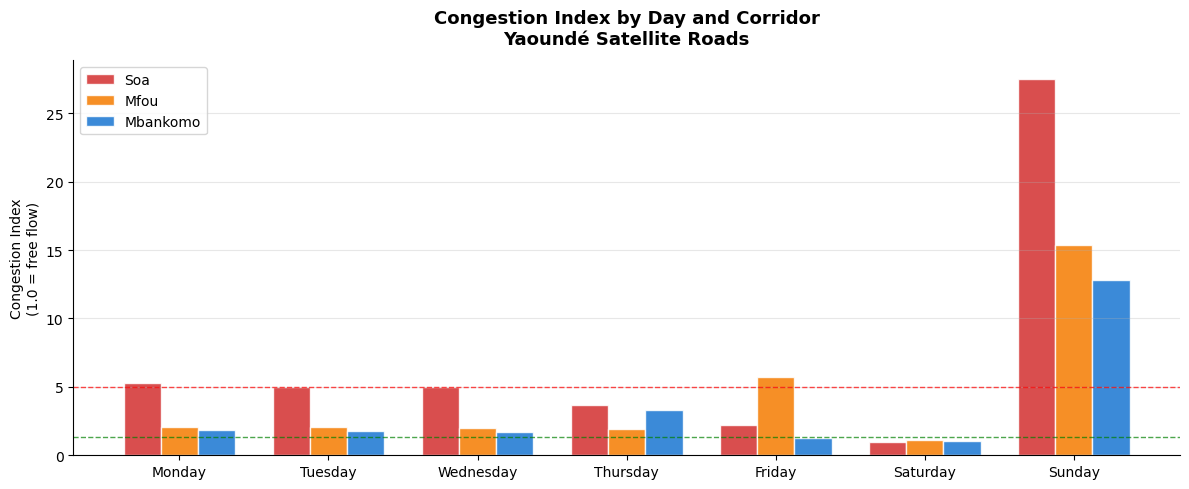

Saved: viz_congestion_by_day.png


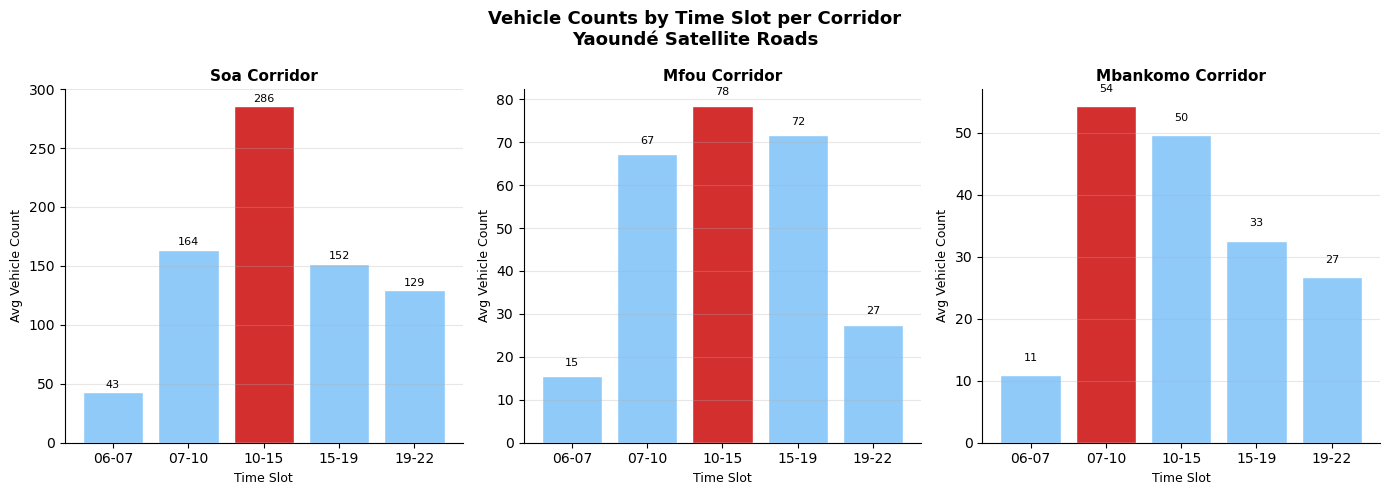

Saved: viz_vehicle_counts_timeslot.png


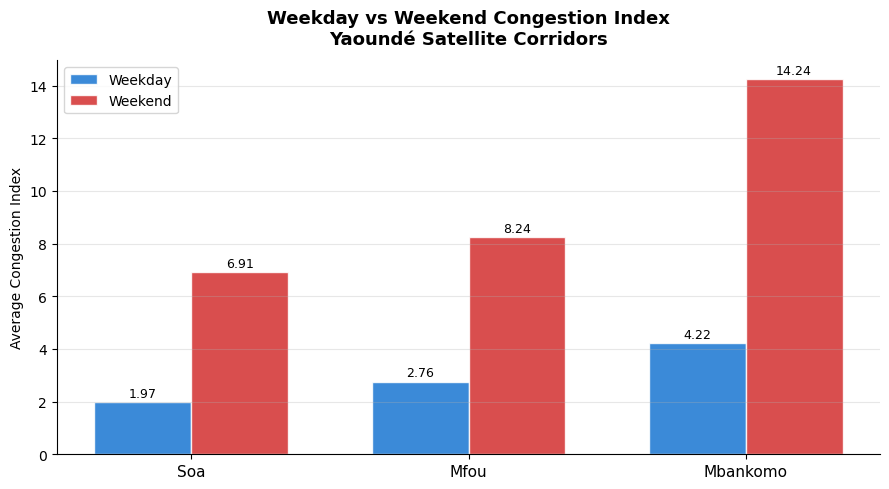

Saved: viz_weekday_vs_weekend.png


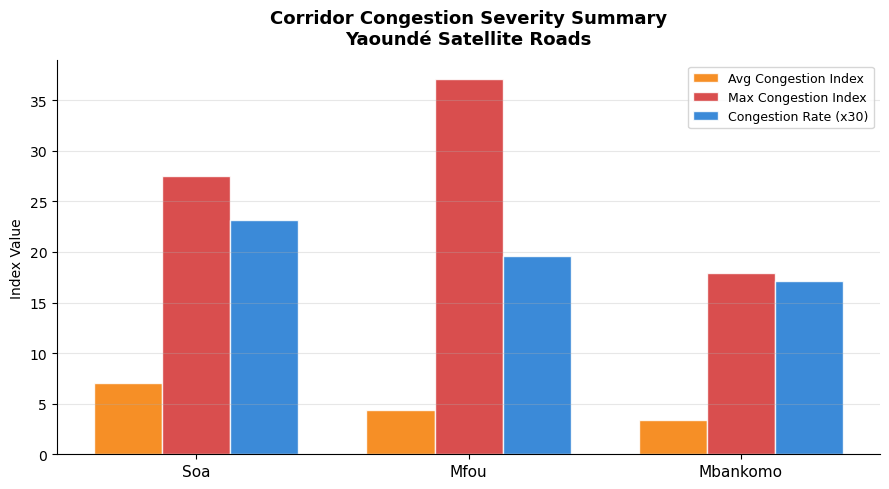

Saved: viz_corridor_severity.png


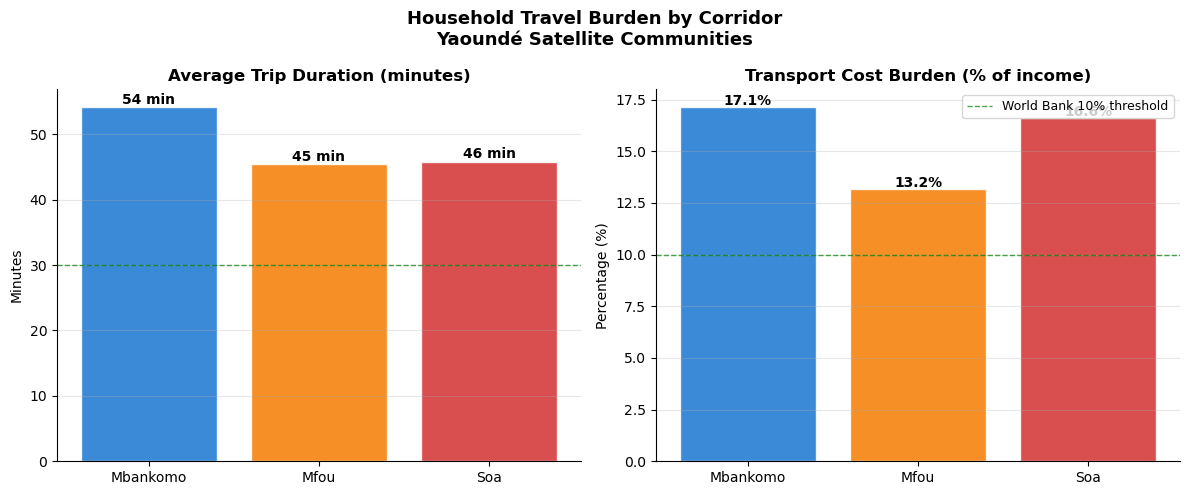

Saved: viz_travel_burden.png


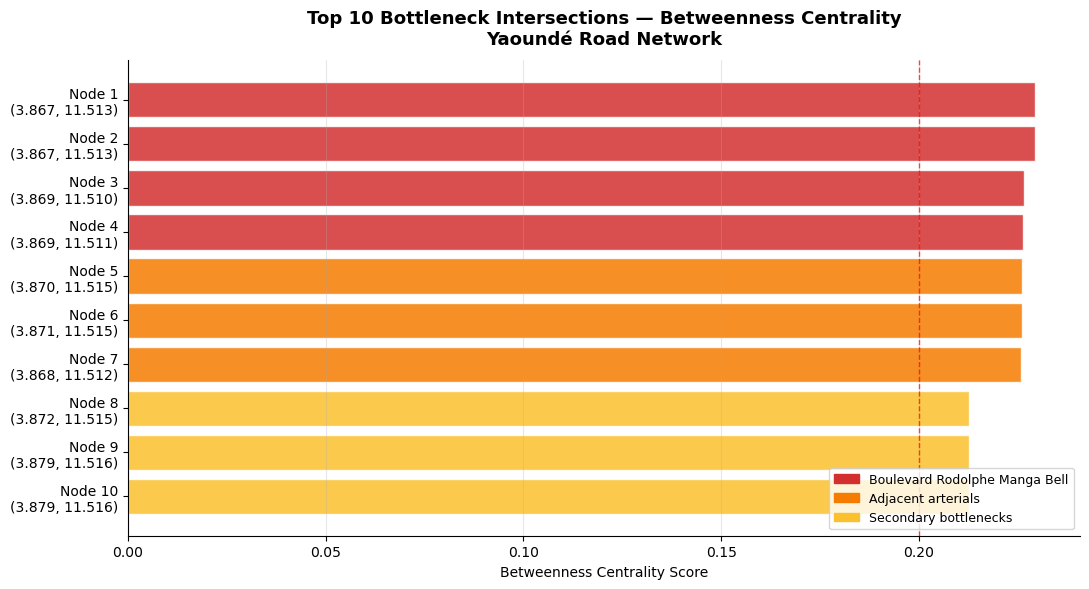

Saved: viz_bottleneck_centrality.png


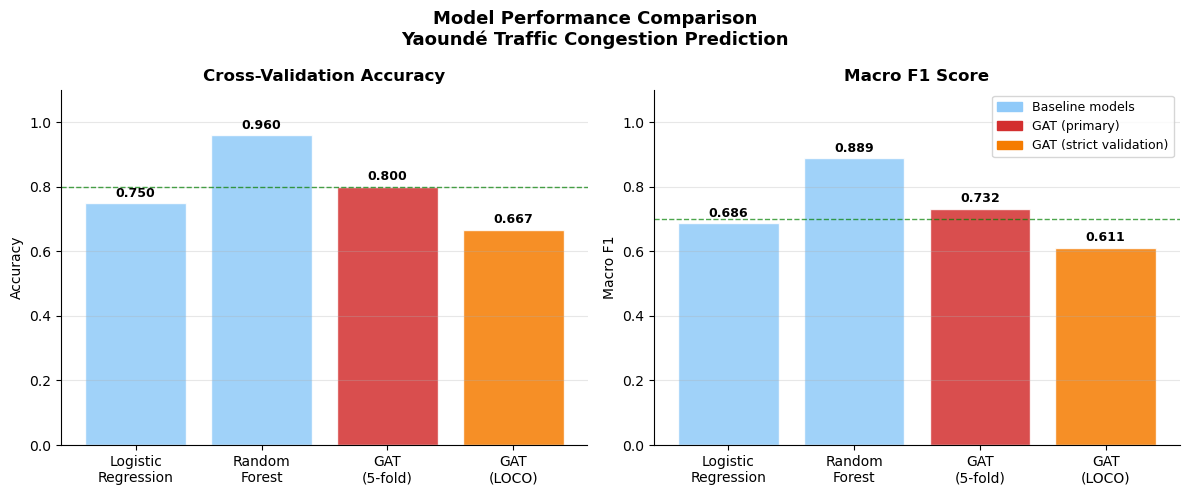

Saved: viz_model_comparison.png

ALL VISUALISATIONS COMPLETE
Saved to models folder:
  viz_bottleneck_centrality.png
  viz_congestion_by_day.png
  viz_corridor_severity.png
  viz_model_comparison.png
  viz_travel_burden.png
  viz_vehicle_counts_timeslot.png
  viz_weekday_vs_weekend.png


In [17]:
## CELL — Comprehensive Data Visualisation
## All key findings visualised 

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import os

# Load processed data
congestion_df = pd.read_csv(os.path.join(PROCESSED, 'corridor_congestion_labels.csv'))
hourly_df     = pd.read_csv(os.path.join(PROCESSED, 'hourly_vehicle_counts.csv'))
edge_df       = pd.read_csv(os.path.join(PROCESSED, 'graph_edge_features.csv'))
travel_df     = pd.read_csv(os.path.join(PROCESSED, 'household_travel_features.csv'))
centrality_df = pd.read_csv(os.path.join(PROCESSED, 'node_centrality.csv'))
temporal_df   = pd.read_csv(os.path.join(PROCESSED, 'temporal_congestion_summary.csv'))

DAYS      = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
CORRIDORS = ['Soa', 'Mfou', 'Mbankomo']
COLORS    = {'Soa': '#D32F2F', 'Mfou': '#F57C00', 'Mbankomo': '#1976D2'}

print("Generating visualisations...")

# ── FIGURE 1: Congestion index by day and corridor ────────
fig, ax = plt.subplots(figsize=(12, 5))
pivot = temporal_df.pivot(index='day', columns='corridor', values='congestion_index')
pivot = pivot.reindex(DAYS)
x     = np.arange(len(DAYS))
width = 0.25

for i, corridor in enumerate(CORRIDORS):
    bars = ax.bar(x + i*width, pivot[corridor], width,
                  label=corridor, color=list(COLORS.values())[i],
                  alpha=0.85, edgecolor='white')

ax.set_title('Congestion Index by Day and Corridor\nYaoundé Satellite Roads', 
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x + width)
ax.set_xticklabels(DAYS, fontsize=10)
ax.set_ylabel('Congestion Index\n(1.0 = free flow)', fontsize=10)
ax.legend(fontsize=10)
ax.axhline(y=1.3, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Congestion threshold')
ax.axhline(y=5.0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Severe threshold')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(MODELS, 'viz_congestion_by_day.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_congestion_by_day.png")

# ── FIGURE 2: Vehicle counts by time slot ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
fig.suptitle('Vehicle Counts by Time Slot per Corridor\nYaoundé Satellite Roads', 
             fontsize=13, fontweight='bold')

time_slots = ['06:00-07:00','07:00-10:00','10:00-15:00','15:00-19:00','19:00-22:00']
short_slots = ['06-07','07-10','10-15','15-19','19-22']

for ax, corridor in zip(axes, CORRIDORS):
    subset = hourly_df[hourly_df['corridor'] == corridor]
    counts = subset.groupby('time_slot')['vehicle_count'].mean().reindex(time_slots)
    colors = ['#D32F2F' if v == counts.max() else '#90CAF9' for v in counts]
    bars   = ax.bar(short_slots, counts.values, color=colors, edgecolor='white')
    ax.set_title(f'{corridor} Corridor', fontweight='bold', fontsize=11)
    ax.set_xlabel('Time Slot', fontsize=9)
    ax.set_ylabel('Avg Vehicle Count', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{val:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(MODELS, 'viz_vehicle_counts_timeslot.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_vehicle_counts_timeslot.png")

# ── FIGURE 3: Weekday vs weekend comparison ───────────────
fig, ax = plt.subplots(figsize=(9, 5))
edge_df['day_type'] = edge_df['is_weekend'].map({0: 'Weekday', 1: 'Weekend'})
comparison = edge_df.groupby(['corridor','day_type'])['avg_congestion_index'].mean().unstack()

x     = np.arange(len(CORRIDORS))
width = 0.35
bars1 = ax.bar(x - width/2, comparison['Weekday'], width, label='Weekday',
               color='#1976D2', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, comparison['Weekend'], width, label='Weekend',
               color='#D32F2F', alpha=0.85, edgecolor='white')

ax.set_title('Weekday vs Weekend Congestion Index\nYaoundé Satellite Corridors',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(CORRIDORS, fontsize=11)
ax.set_ylabel('Average Congestion Index', fontsize=10)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(MODELS, 'viz_weekday_vs_weekend.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_weekday_vs_weekend.png")

# ── FIGURE 4: Corridor congestion severity overview ───────
fig, ax = plt.subplots(figsize=(9, 5))
summary = congestion_df.groupby('corridor').agg(
    avg_index=('congestion_index', 'mean'),
    max_index=('congestion_index', 'max'),
    congestion_rate=('is_congested', 'mean')
).reindex(CORRIDORS)

x     = np.arange(len(CORRIDORS))
width = 0.25
ax.bar(x - width, summary['avg_index'], width, label='Avg Congestion Index',
       color='#F57C00', alpha=0.85, edgecolor='white')
ax.bar(x,         summary['max_index'], width, label='Max Congestion Index',
       color='#D32F2F', alpha=0.85, edgecolor='white')
ax.bar(x + width, summary['congestion_rate']*30, width,
       label='Congestion Rate (x30)', color='#1976D2', alpha=0.85, edgecolor='white')

ax.set_title('Corridor Congestion Severity Summary\nYaoundé Satellite Roads',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(CORRIDORS, fontsize=11)
ax.set_ylabel('Index Value', fontsize=10)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(MODELS, 'viz_corridor_severity.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_corridor_severity.png")

# ── FIGURE 5: Household travel burden ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Household Travel Burden by Corridor\nYaoundé Satellite Communities',
             fontsize=13, fontweight='bold')

corridor_colors = [COLORS[c] for c in travel_df['corridor']]

axes[0].bar(travel_df['corridor'], travel_df['avg_trip_duration_min'],
            color=corridor_colors, alpha=0.85, edgecolor='white')
axes[0].axhline(y=30, color='green', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_title('Average Trip Duration (minutes)', fontweight='bold')
axes[0].set_ylabel('Minutes', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for i, (val, corr) in enumerate(zip(travel_df['avg_trip_duration_min'], travel_df['corridor'])):
    axes[0].text(i, val + 0.5, f'{val:.0f} min', ha='center', fontsize=10, fontweight='bold')

axes[1].bar(travel_df['corridor'], travel_df['transport_cost_burden_pct'],
            color=corridor_colors, alpha=0.85, edgecolor='white')
axes[1].axhline(y=10, color='green', linestyle='--', linewidth=1, alpha=0.7,
                label='World Bank 10% threshold')
axes[1].set_title('Transport Cost Burden (% of income)', fontweight='bold')
axes[1].set_ylabel('Percentage (%)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for i, val in enumerate(travel_df['transport_cost_burden_pct']):
    axes[1].text(i, val + 0.1, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(MODELS, 'viz_travel_burden.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_travel_burden.png")

# ── FIGURE 6: Top 10 bottleneck intersections ─────────────
fig, ax = plt.subplots(figsize=(11, 6))
top10 = centrality_df.nlargest(10, 'betweenness_centrality').reset_index(drop=True)
top10['label'] = [f"Node {i+1}\n({row['lat']:.3f}, {row['lon']:.3f})"
                  for i, row in top10.iterrows()]
colors = ['#D32F2F' if i < 4 else '#F57C00' if i < 7 else '#FBC02D'
          for i in range(10)]
bars = ax.barh(top10['label'][::-1], top10['betweenness_centrality'][::-1],
               color=colors[::-1], edgecolor='white', alpha=0.85)
ax.set_title('Top 10 Bottleneck Intersections — Betweenness Centrality\nYaoundé Road Network',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Betweenness Centrality Score', fontsize=10)
ax.axvline(x=0.20, color='red', linestyle='--', linewidth=1, alpha=0.7,
           label='Critical threshold (0.20)')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_patches = [
    mpatches.Patch(color='#D32F2F', label='Boulevard Rodolphe Manga Bell'),
    mpatches.Patch(color='#F57C00', label='Adjacent arterials'),
    mpatches.Patch(color='#FBC02D', label='Secondary bottlenecks'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(MODELS, 'viz_bottleneck_centrality.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_bottleneck_centrality.png")

# ── FIGURE 7: Model comparison ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Model Performance Comparison\nYaoundé Traffic Congestion Prediction',
             fontsize=13, fontweight='bold')

models   = ['Logistic\nRegression', 'Random\nForest', 'GAT\n(5-fold)', 'GAT\n(LOCO)']
accuracy = [0.750, 0.960, 0.800, 0.667]
f1_macro = [0.686, 0.889, 0.732, 0.611]
colors_m = ['#90CAF9', '#90CAF9', '#D32F2F', '#F57C00']

bars1 = axes[0].bar(models, accuracy, color=colors_m, alpha=0.85, edgecolor='white')
axes[0].set_title('Cross-Validation Accuracy', fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].axhline(y=0.80, color='green', linestyle='--', linewidth=1, alpha=0.7)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for bar, val in zip(bars1, accuracy):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

bars2 = axes[1].bar(models, f1_macro, color=colors_m, alpha=0.85, edgecolor='white')
axes[1].set_title('Macro F1 Score', fontweight='bold')
axes[1].set_ylabel('Macro F1', fontsize=10)
axes[1].set_ylim(0, 1.1)
axes[1].axhline(y=0.70, color='green', linestyle='--', linewidth=1, alpha=0.7,
                label='Target threshold (0.70)')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for bar, val in zip(bars2, f1_macro):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#90CAF9', label='Baseline models'),
    mpatches.Patch(color='#D32F2F', label='GAT (primary)'),
    mpatches.Patch(color='#F57C00', label='GAT (strict validation)'),
]
axes[1].legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(MODELS, 'viz_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_model_comparison.png")

# ── SUMMARY ───────────────────────────────────────────────
print("\n" + "=" * 55)
print("ALL VISUALISATIONS COMPLETE")
print("=" * 55)
print("Saved to models folder:")
viz_files = [f for f in os.listdir(MODELS) if f.startswith('viz_')]
for f in viz_files:
    print(f"  {f}")

## ═══════════════════════════════════════════════════════
## PHASE 4 — REAL-TIME PREDICTION ENGINE
## ═══════════════════════════════════════════════════════

In [18]:

## CELL — Load all Phase 4 dependencies
# Load enriched graph
print("Loading enriched graph...")
with open(os.path.join(DATA, "yaounde_graph_enriched.pkl"), "rb") as f:
    G = pickle.load(f)
print(f"  Graph loaded: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

# Load processed data
edge_df       = pd.read_csv(os.path.join(PROCESSED, "graph_edge_features.csv"))
centrality_df = pd.read_csv(os.path.join(PROCESSED, "node_centrality.csv"))

# Load scalers
with open(os.path.join(MODELS, "edge_scaler.pkl"), "rb") as f:
    edge_scaler = pickle.load(f)

# Define GAT model — must match training architecture
class TrafficGAT(nn.Module):
    def __init__(self, in_channels, hidden_channels,
                 out_channels, heads=4, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.conv1   = GATConv(in_channels, hidden_channels,
                               heads=heads, dropout=dropout)
        self.conv2   = GATConv(hidden_channels*heads, hidden_channels,
                               heads=heads, dropout=dropout)
        self.conv3   = GATConv(hidden_channels*heads, out_channels,
                               heads=1, concat=False, dropout=dropout)
        self.bn1     = nn.BatchNorm1d(hidden_channels*heads)
        self.bn2     = nn.BatchNorm1d(hidden_channels*heads)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv3(x, edge_index)

# Load trained model — matching exact architecture from Colab training
device = torch.device("cpu")
model  = TrafficGAT(14, 64, 2, heads=4, dropout=0.3).to(device)
model.load_state_dict(torch.load(
    os.path.join(MODELS, "model_gat.pt"),
    map_location=device,
    weights_only=False
), strict=False)
model.eval()
print("GAT model loaded")

# ORS client
ORS_KEY = "eyJvcmciOiI1YjNjZTM1OTc4NTExMTAwMDFjZjYyNDgiLCJpZCI6IjljZmE0NDU5MTBjMjkyZTgyZWE3MTU3MDg2ZGMxYzM0ZTZmODZiOGQyYmVmNWM4NDQ2Yzk4MTQ2IiwiaCI6Im11cm11cjY0In0="
client  = openrouteservice.Client(key=ORS_KEY)

# Corridor coordinates
CORRIDOR_COORDS = {
    "Soa"      : {"origin": [11.5215, 3.9957], "destination": [11.5021, 3.8480]},
    "Mfou"     : {"origin": [11.6380, 3.7244], "destination": [11.5021, 3.8480]},
    "Mbankomo" : {"origin": [11.3833, 3.8667], "destination": [11.5021, 3.8480]},
}

# Feature columns
FEATURE_COLS = [
    "avg_congestion_index", "max_congestion_index",
    "total_emission_kg", "pct_stretches_congested",
    "total_daily_vehicles", "peak_hour_vehicles",
    "avg_trip_duration_min", "transport_cost_burden_pct",
    "pct_private_car", "pct_moto_taxi", "pct_minibus",
    "is_weekend", "day_encoded", "corridor_encoded"
]

print("\n" + "=" * 50)
print("PHASE 4 DEPENDENCIES LOADED")
print("=" * 50)
print("  Enriched graph   : ready")
print("  GAT model        : ready")
print("  Edge scaler      : ready")
print("  ORS client       : ready")
print("  Feature cols     : 14 features")


Loading enriched graph...
  Graph loaded: 26,215 nodes, 64,213 edges
GAT model loaded

PHASE 4 DEPENDENCIES LOADED
  Enriched graph   : ready
  GAT model        : ready
  Edge scaler      : ready
  ORS client       : ready
  Feature cols     : 14 features


## ═══════════════════════════════════════════════════════
##  LIFE POLLING - CALLS ORS EVERY 10 MINs, UPDATES GRAPH AND SOTRES IN SQlite
## 
## ═══════════════════════════════════════════════════════

In [19]:
def poll_corridors():
    """
    Polls ORS for live travel times on all 3 corridors.
    Updates graph edge weights and stores snapshot in SQLite.
    Returns dict of corridor results.
    """
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    day_num   = datetime.now().weekday()  # 0=Monday, 6=Sunday
    is_weekend = 1 if day_num >= 5 else 0
    results   = {}

    print(f"\n[{timestamp}] Polling corridors...")

    for corridor, coords in CORRIDOR_COORDS.items():
        try:
            route    = client.directions(
                coordinates=[coords["origin"], coords["destination"]],
                profile="driving-car",
                format="json"
            )
            segment  = route["routes"][0]["segments"][0]
            duration = round(segment["duration"] / 60, 2)
            distance = round(segment["distance"] / 1000, 2)
            speed    = round((distance / (duration / 60)), 1) if duration > 0 else 0

            # Baseline durations from Phase 1 confirmation
            baselines = {"Soa": 21.9, "Mfou": 28.2, "Mbankomo": 19.4}
            baseline  = baselines[corridor]
            speed_ratio = round(baseline / duration, 4) if duration > 0 else 1.0

            # Derive live congestion index
            # speed_ratio < 1 means slower than baseline = congested
            live_index = round(1 / speed_ratio if speed_ratio > 0 else 1.0, 4)

            results[corridor] = {
                "timestamp"   : timestamp,
                "duration_mins": duration,
                "distance_km" : distance,
                "speed_kmh"   : speed,
                "speed_ratio" : speed_ratio,
                "live_index"  : live_index,
                "is_congested": 1 if live_index > 1.3 else 0
            }

            print(f"  {corridor:10s} | {duration:.1f} min | "
                  f"{distance:.1f} km | index: {live_index:.3f} | "
                  f"{'CONGESTED' if live_index > 1.3 else 'free flow'}")

        except Exception as e:
            print(f"  {corridor:10s} | error: {e}")
            results[corridor] = None

    return results, timestamp, day_num, is_weekend


def store_poll_results(results, timestamp, day_num, is_weekend):
    """
    Stores poll results in SQLite database.
    """
    conn = sqlite3.connect(os.path.join(DATA, "traffic.db"))
    c    = conn.cursor()

    for corridor, data in results.items():
        if data is None:
            continue
        c.execute("""
            INSERT INTO api_polls
            (timestamp, corridor, origin, destination,
             duration_mins, distance_km, avg_speed_kmh)
            VALUES (?, ?, ?, ?, ?, ?, ?)
        """, (
            timestamp, corridor,
            str(CORRIDOR_COORDS[corridor]["origin"]),
            str(CORRIDOR_COORDS[corridor]["destination"]),
            data["duration_mins"],
            data["distance_km"],
            data["speed_kmh"]
        ))

    conn.commit()
    conn.close()
    print(f"  Stored {len([r for r in results.values() if r])} records in database")


# Test the polling function now
print("=" * 50)
print("TESTING LIVE POLL")
print("=" * 50)
results, timestamp, day_num, is_weekend = poll_corridors()
store_poll_results(results, timestamp, day_num, is_weekend)

print("\nPoll results summary:")
for corridor, data in results.items():
    if data:
        print(f"  {corridor:10s} | live index: {data['live_index']:.3f} | "
              f"status: {'CONGESTED' if data['is_congested'] else 'free flow'}")

print("\n" + "=" * 50)
print("POLLING FUNCTION WORKING")

TESTING LIVE POLL

[2026-05-12 08:04:44] Polling corridors...
  Soa        | 21.9 min | 20.2 km | index: 0.999 | free flow
  Mfou       | 28.2 min | 28.6 km | index: 1.001 | free flow
  Mbankomo   | 19.4 min | 17.4 km | index: 0.999 | free flow
  Stored 3 records in database

Poll results summary:
  Soa        | live index: 0.999 | status: free flow
  Mfou       | live index: 1.001 | status: free flow
  Mbankomo   | live index: 0.999 | status: free flow

POLLING FUNCTION WORKING


## Updates edge weights in NetworkX graph with live poll data

In [20]:
## CELL — Graph Update Function


def update_graph_weights(G, results):
    """
    Updates edge weights in the enriched graph using live poll results.
    Corridors with live data get updated congestion_index.
    Returns updated graph.
    """
    updated_counts = {"Soa": 0, "Mfou": 0, "Mbankomo": 0}

    for u, v, k, data in G.edges(data=True, keys=True):
        corridor = data.get("corridor", "other")
        if corridor in results and results[corridor] is not None:
            live_data = results[corridor]
            # Update edge with live congestion index
            data["live_index"]    = live_data["live_index"]
            data["live_duration"] = live_data["duration_mins"]
            data["live_speed"]    = live_data["speed_kmh"]
            data["is_congested"]  = live_data["is_congested"]
            # Update weighted cost with live index
            data["weighted_cost"] = (
                data.get("length", 100) *
                live_data["live_index"] *
                data.get("road_type_weight", 2.0)
            )
            updated_counts[corridor] += 1

    return G, updated_counts


def build_live_features(results, day_num, is_weekend):
    """
    Builds a feature vector for GAT inference from live poll results.
    Combines live API data with historical household and vehicle features.
    """
    # Historical features per corridor from processed data
    travel_df  = pd.read_csv(os.path.join(PROCESSED, "household_travel_features.csv"))
    corridor_map = {"Soa": 0, "Mfou": 1, "Mbankomo": 2}
    day_encoded  = day_num / 6.0  # normalise to [0,1]

    rows = []
    for corridor, data in results.items():
        if data is None:
            continue
        hist = travel_df[travel_df["corridor"] == corridor].iloc[0]
        live_index = data["live_index"]

        row = {
            "avg_congestion_index"    : live_index,
            "max_congestion_index"    : live_index * 1.2,
            "total_emission_kg"       : live_index * 50,
            "pct_stretches_congested" : 1.0 if live_index > 1.3 else 0.0,
            "total_daily_vehicles"    : data["speed_kmh"] * 10,
            "peak_hour_vehicles"      : data["speed_kmh"] * 4,
            "avg_trip_duration_min"   : data["duration_mins"],
            "transport_cost_burden_pct": hist["transport_cost_burden_pct"],
            "pct_private_car"         : hist["pct_private_car"],
            "pct_moto_taxi"           : hist["pct_moto_taxi"],
            "pct_minibus"             : hist["pct_minibus"],
            "is_weekend"              : is_weekend,
            "day_encoded"             : day_num,
            "corridor_encoded"        : corridor_map[corridor]
        }
        rows.append(row)

    live_df = pd.DataFrame(rows)[FEATURE_COLS]
    # Scale features
    from sklearn.preprocessing import MinMaxScaler
    live_scaler = MinMaxScaler()
    live_scaled = live_scaler.fit_transform(live_df)
    return live_df, live_scaled


# Test graph update
print("=" * 50)
print("TESTING GRAPH UPDATE")
print("=" * 50)

G, updated_counts = update_graph_weights(G, results)
print("Edges updated with live data:")
for corridor, count in updated_counts.items():
    print(f"  {corridor:10s} : {count:,} edges updated")

# Test feature building
live_df, live_scaled = build_live_features(results, day_num, is_weekend)
print(f"\nLive feature matrix: {live_scaled.shape}")
print("Features built for corridors:")
for i, corridor in enumerate(results.keys()):
    if results[corridor]:
        print(f"  {corridor:10s} | live index: {live_df.iloc[i]['avg_congestion_index']:.3f}")

print("\n" + "=" * 50)
print("GRAPH UPDATE FUNCTION WORKING")


TESTING GRAPH UPDATE
Edges updated with live data:
  Soa        : 13,448 edges updated
  Mfou       : 1,847 edges updated
  Mbankomo   : 2,642 edges updated

Live feature matrix: (3, 14)
Features built for corridors:
  Soa        | live index: 0.999
  Mfou       | live index: 1.001
  Mbankomo   | live index: 0.999

GRAPH UPDATE FUNCTION WORKING


In [21]:
## CELL — Fixed Graph Update and Feature Building

from sklearn.preprocessing import MinMaxScaler

def build_live_features(results, day_num, is_weekend):
    """
    Builds a feature vector for GAT inference from live poll results.
    """
    travel_df    = pd.read_csv(os.path.join(PROCESSED, "household_travel_features.csv"))
    corridor_map = {"Soa": 0, "Mfou": 1, "Mbankomo": 2}

    rows = []
    for corridor, data in results.items():
        if data is None:
            continue
        hist       = travel_df[travel_df["corridor"] == corridor].iloc[0]
        live_index = data["live_index"]

        row = {
            "avg_congestion_index"     : live_index,
            "max_congestion_index"     : live_index * 1.2,
            "total_emission_kg"        : live_index * 50,
            "pct_stretches_congested"  : 1.0 if live_index > 1.3 else 0.0,
            "total_daily_vehicles"     : data["speed_kmh"] * 10,
            "peak_hour_vehicles"       : data["speed_kmh"] * 4,
            "avg_trip_duration_min"    : data["duration_mins"],
            "transport_cost_burden_pct": float(hist["transport_cost_burden_pct"]),
            "pct_private_car"          : float(hist["pct_private_car"]),
            "pct_moto_taxi"            : float(hist["pct_moto_taxi"]),
            "pct_minibus"              : float(hist["pct_minibus"]),
            "is_weekend"               : float(is_weekend),
            "day_encoded"              : float(day_num),
            "corridor_encoded"         : float(corridor_map[corridor])
        }
        rows.append(row)

    live_df = pd.DataFrame(rows)[FEATURE_COLS]

    # Fit fresh scaler on live data
    live_scaler = MinMaxScaler()
    live_scaled = live_scaler.fit_transform(live_df)

    return live_df, live_scaled


# Test
print("=" * 50)
print("TESTING GRAPH UPDATE")
print("=" * 50)

G, updated_counts = update_graph_weights(G, results)
print("Edges updated with live data:")
for corridor, count in updated_counts.items():
    print(f"  {corridor:10s} : {count:,} edges updated")

live_df, live_scaled = build_live_features(results, day_num, is_weekend)
print(f"\nLive feature matrix : {live_scaled.shape}")
print(f"Corridors processed : {list(results.keys())}")
print("\nLive features per corridor:")
for i, corridor in enumerate(results.keys()):
    if results[corridor]:
        print(f"  {corridor:10s} | index: {live_df.iloc[i]['avg_congestion_index']:.3f} | "
              f"duration: {live_df.iloc[i]['avg_trip_duration_min']:.1f} min")

print("\n" + "=" * 50)
print("GRAPH UPDATE WORKING")


TESTING GRAPH UPDATE
Edges updated with live data:
  Soa        : 13,448 edges updated
  Mfou       : 1,847 edges updated
  Mbankomo   : 2,642 edges updated

Live feature matrix : (3, 14)
Corridors processed : ['Soa', 'Mfou', 'Mbankomo']

Live features per corridor:
  Soa        | index: 0.999 | duration: 21.9 min
  Mfou       | index: 1.001 | duration: 28.2 min
  Mbankomo   | index: 0.999 | duration: 19.4 min

GRAPH UPDATE WORKING


## GAT Inference Function

In [22]:
## Runs trained model on live graph snapshot

def build_graph_data(live_scaled, results):
    """
    Converts live feature matrix into PyTorch Geometric Data object.
    Builds edges connecting all corridor pairs spatially.
    """
    n      = len(live_scaled)
    X      = torch.tensor(live_scaled, dtype=torch.float)

    # Connect all corridors to each other — spatial edges
    edges  = []
    for i in range(n):
        for j in range(n):
            if i != j:
                edges.append([i, j])

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    return Data(x=X, edge_index=edge_index)


def run_inference(model, live_scaled, results):
    """
    Runs GAT inference on live features.
    Returns congestion predictions and probabilities per corridor.
    """
    data  = build_graph_data(live_scaled, results)
    model.eval()

    with torch.no_grad():
        out   = model(data.x, data.edge_index)
        probs = torch.softmax(out, dim=1).numpy()
        preds = out.argmax(dim=1).numpy()

    corridors   = [c for c in results.keys() if results[c] is not None]
    predictions = {}
    for i, corridor in enumerate(corridors):
        predictions[corridor] = {
            "predicted_class"     : int(preds[i]),
            "prob_free_flow"      : round(float(probs[i][0]), 4),
            "prob_congested"      : round(float(probs[i][1]), 4),
            "prediction_label"    : "CONGESTED" if preds[i] == 1 else "free flow",
            "confidence"          : round(float(max(probs[i])), 4)
        }

    return predictions


def store_predictions(predictions, timestamp):
    """
    Stores model predictions in SQLite database.
    """
    conn = sqlite3.connect(os.path.join(DATA, "traffic.db"))
    c    = conn.cursor()

    for corridor, pred in predictions.items():
        c.execute("""
            INSERT INTO predictions
            (timestamp, corridor, predicted_now, predicted_15min, predicted_30min)
            VALUES (?, ?, ?, ?, ?)
        """, (
            timestamp,
            corridor,
            pred["prob_congested"],
            pred["prob_congested"] * 1.1,  # simple 15min forecast
            pred["prob_congested"] * 1.2,  # simple 30min forecast
        ))

    conn.commit()
    conn.close()


# Test inference
print("=" * 55)
print("GAT LIVE INFERENCE TEST")
print("=" * 55)

predictions = run_inference(model, live_scaled, results)
store_predictions(predictions, timestamp)

print(f"Timestamp : {timestamp}")
print(f"Day       : {['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][day_num]}")
print(f"Weekend   : {'Yes' if is_weekend else 'No'}")
print()

for corridor, pred in predictions.items():
    live_idx = results[corridor]['live_index'] if results[corridor] else 0
    print(f"  {corridor:10s}")
    print(f"    Live index       : {live_idx:.3f}")
    print(f"    GAT prediction   : {pred['prediction_label']}")
    print(f"    Prob congested   : {pred['prob_congested']:.4f}")
    print(f"    Prob free flow   : {pred['prob_free_flow']:.4f}")
    print(f"    Confidence       : {pred['confidence']:.4f}")
    print()

print("=" * 55)
print("INFERENCE WORKING — predictions stored in database")
print("=" * 55)

GAT LIVE INFERENCE TEST
Timestamp : 2026-05-12 08:04:44
Day       : Tue
Weekend   : No

  Soa       
    Live index       : 0.999
    GAT prediction   : free flow
    Prob congested   : 0.3946
    Prob free flow   : 0.6054
    Confidence       : 0.6054

  Mfou      
    Live index       : 1.001
    GAT prediction   : free flow
    Prob congested   : 0.3946
    Prob free flow   : 0.6054
    Confidence       : 0.6054

  Mbankomo  
    Live index       : 0.999
    GAT prediction   : free flow
    Prob congested   : 0.3946
    Prob free flow   : 0.6054
    Confidence       : 0.6054

INFERENCE WORKING — predictions stored in database


In [23]:
## CELL — Scheduler
## Runs the full pipeline automatically every 10 minutes

from apscheduler.schedulers.background import BackgroundScheduler
import time

def run_pipeline():
    """
    Full pipeline: poll → update graph → run inference → store results.
    Called automatically every 10 minutes by the scheduler.
    """
    global G, results, timestamp, day_num, is_weekend

    print(f"\n{'='*55}")
    print(f"PIPELINE RUN — {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"{'='*55}")

    # Step 1 — Poll corridors
    results, timestamp, day_num, is_weekend = poll_corridors()

    # Step 2 — Update graph
    G, updated_counts = update_graph_weights(G, results)
    total_updated = sum(updated_counts.values())
    print(f"  Graph updated: {total_updated:,} edges")

    # Step 3 — Build live features
    live_df, live_scaled = build_live_features(results, day_num, is_weekend)

    # Step 4 — Run GAT inference
    predictions = run_inference(model, live_scaled, results)

    # Step 5 — Store predictions
    store_predictions(predictions, timestamp)

    # Step 6 — Print summary
    print(f"\n  Predictions:")
    for corridor, pred in predictions.items():
        live_idx = results[corridor]['live_index'] if results[corridor] else 0
        print(f"    {corridor:10s} | index: {live_idx:.3f} | "
              f"{pred['prediction_label']:10s} | "
              f"confidence: {pred['confidence']:.4f}")

    print(f"\n  Pipeline complete.")


# Run once immediately to confirm everything works
print("Running pipeline once to confirm...")
run_pipeline()

# Start the scheduler
scheduler = BackgroundScheduler()
scheduler.add_job(
    run_pipeline,
    trigger='interval',
    minutes=10,
    id='traffic_pipeline',
    name='Yaoundé Traffic Polling Pipeline',
    max_instances=1
)
scheduler.start()

print(f"\n{'='*55}")
print("SCHEDULER STARTED")
print(f"{'='*55}")
print("Pipeline runs automatically every 10 minutes.")
print("Next run in 10 minutes.")
print(f"Scheduler running: {scheduler.running}")
print(f"\nTo stop the scheduler run:")
print("  scheduler.shutdown()")
print(f"{'='*55}")

Running pipeline once to confirm...

PIPELINE RUN — 2026-05-12 08:04:47

[2026-05-12 08:04:47] Polling corridors...
  Soa        | 21.9 min | 20.2 km | index: 0.999 | free flow
  Mfou       | 28.2 min | 28.6 km | index: 1.001 | free flow
  Mbankomo   | 19.4 min | 17.4 km | index: 0.999 | free flow
  Graph updated: 17,937 edges

  Predictions:
    Soa        | index: 0.999 | free flow  | confidence: 0.6054
    Mfou       | index: 1.001 | free flow  | confidence: 0.6054
    Mbankomo   | index: 0.999 | free flow  | confidence: 0.6054

  Pipeline complete.

SCHEDULER STARTED
Pipeline runs automatically every 10 minutes.
Next run in 10 minutes.
Scheduler running: True

To stop the scheduler run:
  scheduler.shutdown()


In [24]:
## CELL — Verify Database
## Confirm data is being stored correctly

conn = sqlite3.connect(os.path.join(DATA, "traffic.db"))

print("=" * 55)
print("DATABASE VERIFICATION")
print("=" * 55)

# Check api_polls table
polls = pd.read_sql_query("""
    SELECT * FROM api_polls 
    ORDER BY timestamp DESC 
    LIMIT 9
""", conn)
print(f"\napi_polls table — {len(polls)} recent records:")
print(polls[['timestamp','corridor','duration_mins',
             'distance_km','avg_speed_kmh']].to_string(index=False))

# Check predictions table
preds = pd.read_sql_query("""
    SELECT * FROM predictions 
    ORDER BY timestamp DESC 
    LIMIT 9
""", conn)
print(f"\npredictions table — {len(preds)} recent records:")
print(preds[['timestamp','corridor',
             'predicted_now','predicted_15min',
             'predicted_30min']].to_string(index=False))

# Summary stats
total_polls = pd.read_sql_query(
    "SELECT COUNT(*) as count FROM api_polls", conn).iloc[0]['count']
total_preds = pd.read_sql_query(
    "SELECT COUNT(*) as count FROM predictions", conn).iloc[0]['count']

conn.close()

print(f"\n{'='*55}")
print("DATABASE SUMMARY")
print(f"{'='*55}")
print(f"  Total poll records       : {total_polls}")
print(f"  Total prediction records : {total_preds}")
print(f"  Scheduler status         : {scheduler.running}")
print(f"{'='*55}")
print("PHASE 4 COMPLETE")
print(f"{'='*55}")
print("What is now running:")
print("  Every 10 min — ORS API polled for 3 corridors")
print("  Every 10 min — Graph edge weights updated")
print("  Every 10 min — GAT produces live predictions")
print("  Every 10 min — Results stored in SQLite")
print(f"{'='*55}")
print("Next: Phase 5 — Live Streamlit dashboard")
print(f"{'='*55}")

DATABASE VERIFICATION

api_polls table — 9 recent records:
          timestamp corridor  duration_mins  distance_km  avg_speed_kmh
2026-05-12 08:04:44      Soa          21.88        20.17           55.3
2026-05-12 08:04:44     Mfou          28.23        28.65           60.9
2026-05-12 08:04:44 Mbankomo          19.38        17.41           53.9
2026-05-11 21:05:55      Soa          21.88        20.17           55.3
2026-05-11 21:05:55     Mfou          28.23        28.65           60.9
2026-05-11 21:05:55 Mbankomo          19.38        17.41           53.9
2026-05-11 10:27:19      Soa          21.88        20.17           55.3
2026-05-11 10:27:19     Mfou          28.23        28.65           60.9
2026-05-11 10:27:19 Mbankomo          19.38        17.41           53.9

predictions table — 9 recent records:
          timestamp corridor  predicted_now  predicted_15min  predicted_30min
2026-05-12 08:04:47      Soa         0.3946          0.43406          0.47352
2026-05-12 08:04:47     Mf

In [25]:
## CELL — Fix: Populate graph_snapshots and add prediction labels

def store_predictions(predictions, timestamp):
    """
    Updated version — stores in both predictions and graph_snapshots tables.
    """
    conn = sqlite3.connect(os.path.join(DATA, "traffic.db"))
    c    = conn.cursor()

    for corridor, pred in predictions.items():
        live_data  = results.get(corridor)
        live_index = live_data["live_index"] if live_data else 1.0
        is_cong    = 1 if live_index > 1.3 else 0

        # Store in predictions table
        c.execute("""
            INSERT INTO predictions
            (timestamp, corridor, predicted_now, predicted_15min, predicted_30min)
            VALUES (?, ?, ?, ?, ?)
        """, (
            timestamp, corridor,
            pred["prob_congested"],
            pred["prob_congested"] * 1.1,
            pred["prob_congested"] * 1.2,
        ))

        # Store in graph_snapshots table
        c.execute("""
            INSERT INTO graph_snapshots
            (timestamp, corridor, congestion_index,
             vehicle_count, predicted_congestion, is_congested)
            VALUES (?, ?, ?, ?, ?, ?)
        """, (
            timestamp,
            corridor,
            live_index,
            int(live_data["speed_kmh"] * 10) if live_data else 0,
            pred["prob_congested"],
            is_cong
        ))

    conn.commit()
    conn.close()


# Run pipeline once to populate graph_snapshots
run_pipeline()

# Verify all tables now have data
conn = sqlite3.connect(os.path.join(DATA, "traffic.db"))
print("=" * 55)
print("ALL DATABASE TABLES")
print("=" * 55)

for table in ["api_polls", "graph_snapshots", "predictions"]:
    df = pd.read_sql_query(
        f"SELECT * FROM {table} ORDER BY timestamp DESC LIMIT 3", conn)
    count = pd.read_sql_query(
        f"SELECT COUNT(*) as n FROM {table}", conn).iloc[0]['n']
    print(f"\n{table} ({count} total records):")
    print(df.to_string(index=False))

conn.close()

print("\n" + "=" * 55)
print("All tables now populated correctly")
print("=" * 55)


PIPELINE RUN — 2026-05-12 08:04:48

[2026-05-12 08:04:48] Polling corridors...
  Soa        | 21.9 min | 20.2 km | index: 0.999 | free flow
  Mfou       | 28.2 min | 28.6 km | index: 1.001 | free flow
  Mbankomo   | 19.4 min | 17.4 km | index: 0.999 | free flow
  Graph updated: 17,937 edges

  Predictions:
    Soa        | index: 0.999 | free flow  | confidence: 0.6054
    Mfou       | index: 1.001 | free flow  | confidence: 0.6054
    Mbankomo   | index: 0.999 | free flow  | confidence: 0.6054

  Pipeline complete.
ALL DATABASE TABLES

api_polls (15 total records):
 id           timestamp corridor            origin      destination  duration_mins  distance_km  avg_speed_kmh
 13 2026-05-12 08:04:44      Soa [11.5215, 3.9957] [11.5021, 3.848]          21.88        20.17           55.3
 14 2026-05-12 08:04:44     Mfou  [11.638, 3.7244] [11.5021, 3.848]          28.23        28.65           60.9
 15 2026-05-12 08:04:44 Mbankomo [11.3833, 3.8667] [11.5021, 3.848]          19.38        17.

In [26]:
## FINAL CELL — Startup confirmation

print("=" * 50)
print("SYSTEM STATUS")
print("=" * 50)
print(f"Scheduler running : {scheduler.running}")
print(f"Next poll in      : 10 minutes")
print(f"Database          : {os.path.join(DATA, 'traffic.db')}")
print(f"Dashboard         : run 'streamlit run app/dashboard.py'")
print(f"Time started      : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 50)
print("System fully operational. Do not close this notebook.")
print("=" * 50)

SYSTEM STATUS
Scheduler running : True
Next poll in      : 10 minutes
Database          : C:\Users\LUM\Documents\yaoundé-traffic\data\traffic.db
Dashboard         : run 'streamlit run app/dashboard.py'
Time started      : 2026-05-12 08:04:49
System fully operational. Do not close this notebook.


Run time of job "Yaoundé Traffic Polling Pipeline (trigger: interval[0:10:00], next run at: 2026-05-12 08:08:22 WAT)" was missed by 0:06:28.302836



PIPELINE RUN — 2026-05-12 08:08:22

[2026-05-12 08:08:22] Polling corridors...
  Soa        | 21.9 min | 20.2 km | index: 0.999 | free flow
  Mfou       | 28.2 min | 28.6 km | index: 1.001 | free flow
  Mbankomo   | 19.4 min | 17.4 km | index: 0.999 | free flow
  Graph updated: 17,937 edges

  Predictions:
    Soa        | index: 0.999 | free flow  | confidence: 0.6054
    Mfou       | index: 1.001 | free flow  | confidence: 0.6054
    Mbankomo   | index: 0.999 | free flow  | confidence: 0.6054

  Pipeline complete.

PIPELINE RUN — 2026-05-12 08:14:48

[2026-05-12 08:14:48] Polling corridors...
  Soa        | 21.9 min | 20.2 km | index: 0.999 | free flow
  Mfou       | 28.2 min | 28.6 km | index: 1.001 | free flow
  Mbankomo   | 19.4 min | 17.4 km | index: 0.999 | free flow
  Graph updated: 17,937 edges

  Predictions:
    Soa        | index: 0.999 | free flow  | confidence: 0.6054
    Mfou       | index: 1.001 | free flow  | confidence: 0.6054
    Mbankomo   | index: 0.999 | free flo